# 06 Hidden Markov Model

This notebook applies a Gaussian Hidden Markov Model (HMM) to identify latent market regimes in the cryptocurrency market. Unlike the k-Means clustering in notebook `05`, the HMM is a generative sequence model that explicitly captures the temporal ordering of observations and the probability of transitioning between hidden states over time.

## Task

Unsupervised regime detection: assign each trading day to one of $K$ latent market states (e.g. low-volatility bull regime, high-volatility bear regime) based on the same daily market feature matrix used in notebook `05`.

## Method

A Gaussian HMM with full covariance matrices is fitted to the standardized daily feature matrix. The model is trained via the Baum-Welch (EM) algorithm. The number of hidden states is selected by comparing BIC scores across candidate values of $K \in \{2, 3, 4, 5, 6, 7\}$. To reduce the risk of converging to a local optimum, the final model is fitted `N_RESTARTS` times with different random seeds and the run with the highest log-likelihood is kept. The Viterbi algorithm then decodes the most likely state sequence for the full observation period.

In [92]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm

import mlflow

sys.path.append(str(Path.cwd().resolve().parent))
from mlflow_utils import get_or_create_experiment, EXPERIMENT_HMM
from src.utils.plot_config import COIN_COLORS, apply_plot_style

warnings.filterwarnings("ignore", category=DeprecationWarning)

apply_plot_style()

# Re-apply background settings after seaborn initializes,
# as seaborn can override these during its own setup.
mpl.rcParams["figure.facecolor"] = "#F9F7FC"
mpl.rcParams["axes.facecolor"]   = "#FFFFFF"
mpl.rcParams["font.family"]      = "sans-serif"

get_or_create_experiment(EXPERIMENT_HMM)
mlflow.set_experiment(EXPERIMENT_HMM)

<Experiment: artifact_location='file:///home/theodora/PycharmProjects/HSLU_FS26_DSPRO2/mlruns/590675346676737577', creation_time=1777232281102, experiment_id='590675346676737577', last_update_time=1777232281102, lifecycle_stage='active', name='hmm_regime_detection', tags={}, trace_location=None, workspace='default'>

## Configuration
All paths and hyperparameter search ranges are defined here so they can be adjusted in one place.

In [93]:
PROJECT_ROOT = Path.cwd().resolve().parent

DATA_PROCESSED_DIR     = PROJECT_ROOT / "data" / "processed"
DATA_MODEL_OUTPUTS_DIR = PROJECT_ROOT / "data" / "model_outputs"

# Input paths (outputs from notebook 02)
FEATURES_LONG_ALIGNED_PATH = DATA_PROCESSED_DIR / "crypto_features_long_aligned.csv"

# Output path (regime labels are model outputs, not processed features)
HMM_REGIME_LABELS_OUTPUT_PATH = DATA_MODEL_OUTPUTS_DIR / "hmm_regime_labels.csv"

# Model selection range
N_STATES_RANGE = range(2, 8)  # candidate values: 2, 3, 4, 5, 6, 7

RANDOM_STATE    = 42    # seed used for the sweep runs
N_ITER          = 500   # maximum EM iterations
N_RESTARTS      = 10    # number of random restarts for the final model
COVARIANCE_TYPE = "full"  # full covariance matrix per state

## Load data

In [94]:
features_long_df = pd.read_csv(FEATURES_LONG_ALIGNED_PATH, parse_dates=["Date"])

print("Features long shape:", features_long_df.shape)
print("Date range:", features_long_df["Date"].min().date(), "to", features_long_df["Date"].max().date())

Features long shape: (13044, 15)
Date range: 2020-04-10 to 2026-03-23


## Build the daily market feature matrix
The same aggregation logic used in notebook `05` is applied here. Each row represents one trading day. The feature matrix summarizes market-wide behavior using cross-sectional statistics and macro variables.

In [95]:
def build_daily_market_features(features_long: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate per-asset features into daily market-state summaries.

    Returns a DataFrame indexed by Date with one row per trading day.
    """
    altcoin_df = features_long[features_long["Ticker"] != "BTC"]

    # Cross-sectional return statistics across all assets
    return_stats = features_long.groupby("Date")["log_return"].agg(
        mean_log_return="mean",
        return_dispersion="std",
    )

    # Average 30-day rolling volatility across all assets
    mean_vol = features_long.groupby("Date")["volatility_30d"].mean().rename("mean_volatility")

    # Average BTC correlation and idiosyncratic volatility (altcoins only)
    mean_btc_corr = altcoin_df.groupby("Date")["btc_corr_30d"].mean().rename("mean_btc_corr")
    mean_idio = altcoin_df.groupby("Date")["idio_vol_30d"].mean().rename("mean_idio_vol")

    # Macro returns (same value for all assets on a given day)
    macro_cols = ["dxy_log_return", "gold_log_return", "sp500_log_return", "vix_log_return"]
    macro_daily = features_long.groupby("Date")[macro_cols].first()

    daily_features = pd.concat(
        [return_stats, mean_vol, mean_btc_corr, mean_idio, macro_daily], axis=1
    )
    return daily_features

In [96]:
daily_features_df = build_daily_market_features(features_long_df)
daily_features_clean_df = daily_features_df.dropna().copy()

print("Daily features shape before dropping NaNs:", daily_features_df.shape)
print("Daily features shape after  dropping NaNs:", daily_features_clean_df.shape)
print(f"Dropped {len(daily_features_df) - len(daily_features_clean_df)} rows")

daily_features_clean_df.head()

Daily features shape before dropping NaNs: (2174, 9)
Daily features shape after  dropping NaNs: (2144, 9)
Dropped 30 rows


,mean_log_return,return_dispersion,mean_volatility,mean_btc_corr,mean_idio_vol,dxy_log_return,gold_log_return,sp500_log_return,vix_log_return
Date,,,,,,,,,
2020-05-10,-0.107129,0.014830,0.047262,0.722147,0.034981,0.000000,0.000000,0.000000,0.000000
2020-05-11,-0.020996,0.010383,0.046322,0.729057,0.033585,0.005101,-0.008575,0.000133,-0.014762
2020-05-12,0.030535,0.012004,0.045797,0.734064,0.032777,-0.003097,0.005353,-0.020713,0.180991
2020-05-13,0.033102,0.014469,0.045399,0.742890,0.031832,0.003097,0.005558,-0.017617,0.065597
2020-05-14,0.023250,0.015059,0.044588,0.746671,0.030742,0.002292,0.014021,0.011459,-0.078697


## Preprocessing
The features are standardized before fitting the HMM. Although the Gaussian HMM learns its own emission means and covariances per state, standardizing ensures that no single feature dominates the covariance structure due to scale differences.

In [97]:
feature_columns = daily_features_clean_df.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(daily_features_clean_df[feature_columns])

print("Scaled feature matrix shape:", X_scaled.shape)
print("\nFeature means after scaling (should be ~0):")
print(pd.Series(X_scaled.mean(axis=0), index=feature_columns).round(6))

Scaled feature matrix shape: (2144, 9)

Feature means after scaling (should be ~0):
mean_log_return     -0.0
return_dispersion    0.0
mean_volatility     -0.0
mean_btc_corr       -0.0
mean_idio_vol       -0.0
dxy_log_return       0.0
gold_log_return      0.0
sp500_log_return     0.0
vix_log_return      -0.0
dtype: float64


## Model selection
A separate GaussianHMM is fitted for each candidate value of $K$. Model complexity is penalized using the Bayesian Information Criterion (BIC):

$$
\text{BIC} = -2 \cdot \log \hat{L} + p \cdot \log(T)
$$

where $\hat{L}$ is the maximized likelihood, $p$ is the number of free parameters, and $T$ is the number of observations.

A lower BIC indicates a better balance between fit and complexity.

In [98]:
def count_hmm_parameters(model: hmm.GaussianHMM, n_features: int) -> int:
    """
    Count the number of free parameters in a fitted GaussianHMM.

    For a model with K states and D features (full covariance):
      - Initial state probabilities: K - 1
      - Transition matrix:          K * (K - 1)
      - Emission means:             K * D
      - Emission covariances:       K * D * (D + 1) / 2  (symmetric matrix)
    """
    k = model.n_components
    d = n_features
    n_params = (k - 1) + k * (k - 1) + k * d + k * d * (d + 1) // 2
    return n_params

In [99]:
FEATURES_USED = ",".join(feature_columns)
T, D = X_scaled.shape

sweep_results = []

for n_states in N_STATES_RANGE:
    with mlflow.start_run(run_name=f"hmm_sweep_k={n_states}"):
        model = hmm.GaussianHMM(
            n_components=n_states,
            covariance_type=COVARIANCE_TYPE,
            n_iter=N_ITER,
            random_state=RANDOM_STATE,
        )
        model.fit(X_scaled)

        log_likelihood = model.score(X_scaled)
        n_params = count_hmm_parameters(model, D)
        bic = -2 * log_likelihood * T + n_params * np.log(T)
        aic = -2 * log_likelihood * T + 2 * n_params

        mlflow.log_param("algorithm", "gaussian_hmm")
        mlflow.log_param("n_states", n_states)
        mlflow.log_param("covariance_type", COVARIANCE_TYPE)
        mlflow.log_param("n_iter", N_ITER)
        mlflow.log_param("random_state", RANDOM_STATE)
        mlflow.log_param("n_observations", T)
        mlflow.log_param("n_features", D)
        mlflow.log_param("features_used", FEATURES_USED)
        mlflow.log_param("n_free_params", n_params)
        mlflow.log_param("dataset", "aligned_6_assets_from_2020")

        mlflow.log_metric("log_likelihood", log_likelihood)
        mlflow.log_metric("bic", bic)
        mlflow.log_metric("aic", aic)

        sweep_results.append({
            "n_states": n_states,
            "log_likelihood": log_likelihood,
            "n_params": n_params,
            "bic": bic,
            "aic": aic,
        })

        print(f"n_states={n_states}  log_likelihood={log_likelihood:.2f}  BIC={bic:.2f}  AIC={aic:.2f}")

sweep_df = pd.DataFrame(sweep_results).set_index("n_states")
sweep_df

n_states=2  log_likelihood=-19047.31  BIC=81675737.70  AIC=81675108.28
n_states=3  log_likelihood=-2155.06  BIC=9242219.88  AIC=9241255.91
n_states=4  log_likelihood=-1308.63  BIC=5613187.28  AIC=5611877.41
n_states=5  log_likelihood=-852.89  BIC=3659456.67  AIC=3657789.56


Model is not converging.  Current: -1138.8042288670747 is not greater than 2140.5478070399004. Delta is -3279.3520359069753


n_states=6  log_likelihood=-818.71  BIC=3513363.06  AIC=3511327.38


Model is not converging.  Current: -1237.8178950100257 is not greater than 14072.80602315578. Delta is -15310.623918165806


n_states=7  log_likelihood=-1117.10  BIC=4793407.12  AIC=4790991.51


,log_likelihood,n_params,bic,aic
n_states,,,,
2,-19047.314897,111,8.167574e+07,8.167511e+07
3,-2155.064344,170,9.242220e+06,9.241256e+06
4,-1308.632324,231,5.613187e+06,5.611877e+06
5,-852.892155,294,3.659457e+06,3.657790e+06
6,-818.705545,359,3.513363e+06,3.511327e+06
7,-1117.103431,426,4.793407e+06,4.790992e+06


## Model selection plot

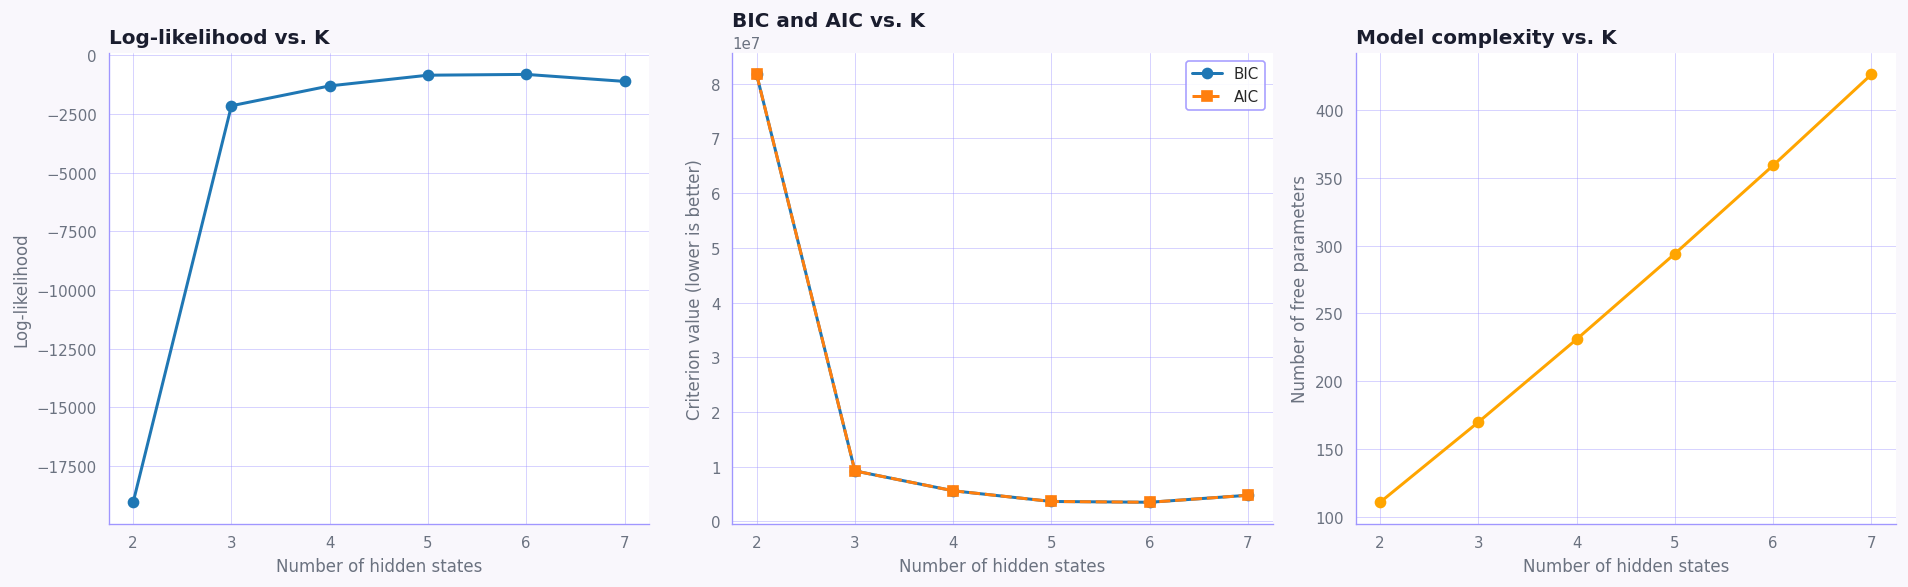

Best K by BIC: 6


In [100]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(sweep_df.index, sweep_df["log_likelihood"], "o-")
axes[0].set_xlabel("Number of hidden states")
axes[0].set_ylabel("Log-likelihood")
axes[0].set_title("Log-likelihood vs. K")
axes[0].set_xticks(list(N_STATES_RANGE))

axes[1].plot(sweep_df.index, sweep_df["bic"], "o-", label="BIC")
axes[1].plot(sweep_df.index, sweep_df["aic"], "s--", label="AIC")
axes[1].set_xlabel("Number of hidden states")
axes[1].set_ylabel("Criterion value (lower is better)")
axes[1].set_title("BIC and AIC vs. K")
axes[1].set_xticks(list(N_STATES_RANGE))
axes[1].legend()

axes[2].plot(sweep_df.index, sweep_df["n_params"], "o-", color="orange")
axes[2].set_xlabel("Number of hidden states")
axes[2].set_ylabel("Number of free parameters")
axes[2].set_title("Model complexity vs. K")
axes[2].set_xticks(list(N_STATES_RANGE))

plt.tight_layout()
plt.show()

best_k_bic = int(sweep_df["bic"].idxmin())
print(f"Best K by BIC: {best_k_bic}")

<div class="alert alert-block alert-info">
<b>Model selection note:</b> The BIC finds a minimum at K=6, however the sweep produced convergence warnings for both K=6 and K=7, meaning the EM algorithm did not reach a stable solution at those complexities. A BIC value from a non-converged model is not reliable. Combined with the fact that log-likelihood gains beyond K=3 are marginal, K=4 is chosen as the final model to balance fit, stability, and interpretability.
</div>

## Final model
The final model uses $K=4$ hidden states. To reduce the risk of the Baum-Welch algorithm converging to a local optimum, the model is fitted `N_RESTARTS` times with different random seeds. The run with the highest log-likelihood is kept. The Viterbi algorithm then decodes the most likely hidden state sequence for every trading day.

In [101]:
#FINAL_N_STATES = best_k_bic

# The BIC selects K=6, however convergence warnings at K=6 and K=7 indicate the EM algorithm did not reach a stable solution at those complexities.
# Log-likelihood gains beyond K=3 are also marginal. K=4 is chosen to balance fit, stability, and interpretability.

FINAL_N_STATES = 4

best_model = None
best_score = -np.inf
best_seed  = None

for restart in range(N_RESTARTS):
    candidate = hmm.GaussianHMM(
        n_components=FINAL_N_STATES,
        covariance_type=COVARIANCE_TYPE,
        n_iter=N_ITER,
        random_state=restart,
    )
    candidate.fit(X_scaled)
    score = candidate.score(X_scaled)
    if score > best_score:
        best_score = score
        best_model = candidate
        best_seed  = restart

final_model   = best_model
regime_labels = final_model.predict(X_scaled)

# Define state colors here so all downstream plot cells are self-contained and do not depend on a specific cell having run first.
colors = plt.cm.Set1(np.linspace(0, 0.8, FINAL_N_STATES))

log_likelihood = final_model.score(X_scaled)
n_params = count_hmm_parameters(final_model, D)
bic = -2 * log_likelihood * T + n_params * np.log(T)
aic = -2 * log_likelihood * T + 2 * n_params

# Open the MLflow run without a context manager so it stays open across cells until the output file is saved and logged.
final_run = mlflow.start_run(run_name=f"hmm_final_k={FINAL_N_STATES}")

mlflow.log_param("algorithm", "gaussian_hmm")
mlflow.log_param("n_states", FINAL_N_STATES)
mlflow.log_param("covariance_type", COVARIANCE_TYPE)
mlflow.log_param("n_iter", N_ITER)
mlflow.log_param("n_restarts", N_RESTARTS)
mlflow.log_param("best_seed", best_seed)
mlflow.log_param("n_observations", T)
mlflow.log_param("n_features", D)
mlflow.log_param("features_used", FEATURES_USED)
mlflow.log_param("n_free_params", n_params)
mlflow.log_param("dataset", "aligned_6_assets_from_2020")
mlflow.set_tag("stage", "final")

mlflow.log_metric("log_likelihood", log_likelihood)
mlflow.log_metric("bic", bic)
mlflow.log_metric("aic", aic)

for state_id, count in pd.Series(regime_labels).value_counts().sort_index().items():
    mlflow.log_metric(f"state_{state_id}_size", int(count))

FINAL_RUN_ID = final_run.info.run_id

print(f"Final HMM with K={FINAL_N_STATES}")
print(f"Best restart seed: {best_seed}")
print(f"Log-likelihood:    {log_likelihood:.4f}")
print(f"BIC:               {bic:.2f}")
print(f"AIC:               {aic:.2f}")
print(f"MLflow run_id:     {FINAL_RUN_ID}")
print("\nRegime sizes:")
print(pd.Series(regime_labels).value_counts().sort_index())

Final HMM with K=4
Best restart seed: 8
Log-likelihood:    -1219.9418
BIC:               5232882.27
AIC:               5231572.40
MLflow run_id:     d0d5d09c2a2b4c7cbc29b706882d7c31

Regime sizes:
0    666
1    625
2    377
3    476
Name: count, dtype: int64


## Regime analysis
The emission parameters (means and covariances) of each hidden state are inspected to attach economic interpretations to the regimes.

In [102]:
# Emission means per state in the original (unscaled) feature space
emission_means_scaled = pd.DataFrame(
    final_model.means_,
    columns=feature_columns,
    index=[f"State {i}" for i in range(FINAL_N_STATES)],
)

# Invert scaling to get interpretable units
emission_means_orig = pd.DataFrame(
    scaler.inverse_transform(final_model.means_),
    columns=feature_columns,
    index=[f"State {i}" for i in range(FINAL_N_STATES)],
)

print("Emission means (original scale):")
emission_means_orig.round(4)

Emission means (original scale):


,mean_log_return,return_dispersion,mean_volatility,mean_btc_corr,mean_idio_vol,dxy_log_return,gold_log_return,sp500_log_return,vix_log_return
State 0,0.0023,0.0208,0.0394,0.6769,0.0287,-0.0000,-0.0000,0.0000,0.0000
State 1,0.0030,0.0201,0.0284,0.6336,0.0220,-0.0000,0.0011,0.0013,-0.0020
State 2,0.0005,0.0418,0.0603,0.6184,0.0468,-0.0002,0.0002,0.0001,0.0049
State 3,-0.0013,0.0188,0.0389,0.7890,0.0235,0.0002,0.0005,-0.0001,-0.0013


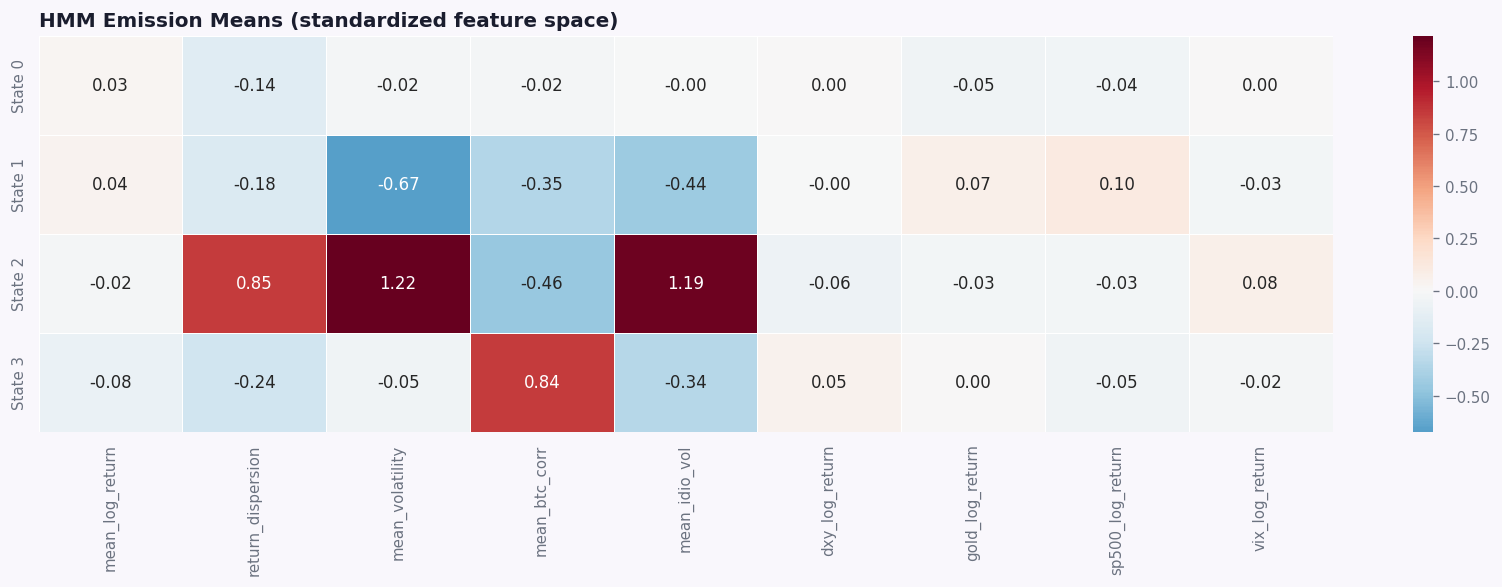

In [103]:
# Heatmap of emission means in the standardized feature space for easier comparison
fig, ax = plt.subplots(figsize=(14, max(3, FINAL_N_STATES + 1)))
sns.heatmap(
    emission_means_scaled,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("HMM Emission Means (standardized feature space)")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<b>Regime interpretation:</b> <br>
State 2 is a high-volatility, low-BTC-correlation regime consistent with turbulent or crisis periods where altcoins decouple from Bitcoin and idiosyncratic volatility spikes. <br>
State 3 is a high-BTC-correlation, low-idiosyncratic-volatility regime representing a concentrated market where altcoins closely track Bitcoin with limited diversification potential. <br>
State 1 is a low-volatility, low-BTC-correlation regime that likely captures calmer periods with some diversification opportunity. <br>
State 0 shows near-zero values across all features and functions as a neutral baseline rather than a structurally distinct market regime.
</div>

## Regime labels over time
The decoded state sequence is plotted alongside the BTC price to visually assess whether the detected regimes correspond to recognizable market phases.

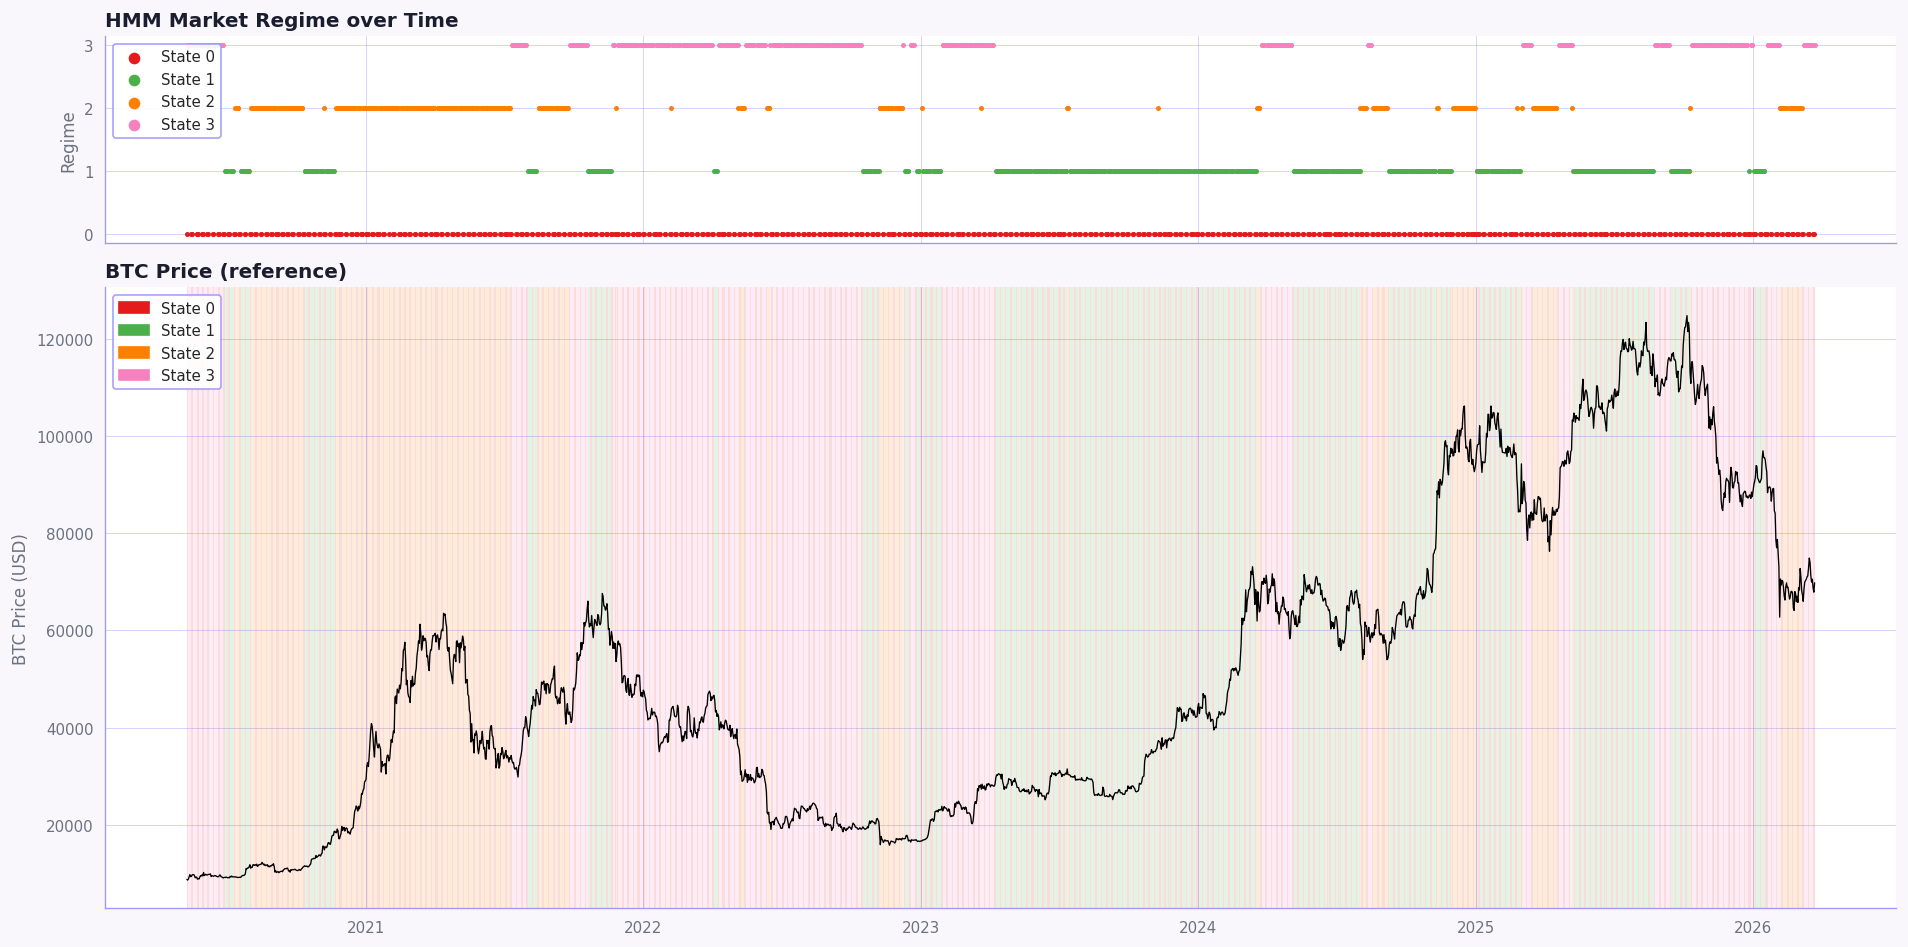

In [104]:
daily_features_clean_df["hmm_regime"] = regime_labels

dates = daily_features_clean_df.index

fig, axes = plt.subplots(
    2, 1, figsize=(16, 8), sharex=True, gridspec_kw={"height_ratios": [1, 3]}
)

# Top panel: regime sequence
for state in range(FINAL_N_STATES):
    mask = regime_labels == state
    axes[0].scatter(
        dates[mask], regime_labels[mask], color=colors[state], s=4, label=f"State {state}"
    )
axes[0].set_ylabel("Regime")
axes[0].set_yticks(range(FINAL_N_STATES))
axes[0].set_title("HMM Market Regime over Time")
axes[0].legend(loc="upper left", markerscale=3)

# Bottom panel: BTC price with regime shading
btc_close = pd.read_csv(
    DATA_PROCESSED_DIR / "crypto_wide_close_aligned.csv",
    parse_dates=["Date"],
    index_col="Date",
)["BTC"]
btc_close_filtered = btc_close.loc[dates[0]:dates[-1]]

axes[1].plot(btc_close_filtered.index, btc_close_filtered.values, color="black", linewidth=0.8)
axes[1].set_ylabel("BTC Price (USD)")
axes[1].set_title("BTC Price (reference)")

for i in range(len(dates) - 1):
    axes[1].axvspan(
        dates[i], dates[i + 1],
        alpha=0.15,
        color=colors[regime_labels[i]],
        linewidth=0,
    )

legend_patches = [mpatches.Patch(color=colors[s], label=f"State {s}") for s in range(FINAL_N_STATES)]
axes[1].legend(handles=legend_patches, loc="upper left")

plt.tight_layout()
plt.show()

## Transition matrix
The learned transition matrix $A$ gives the probability of moving from state $i$ to state $j$ on consecutive trading days. High diagonal values indicate that regimes are persistent.

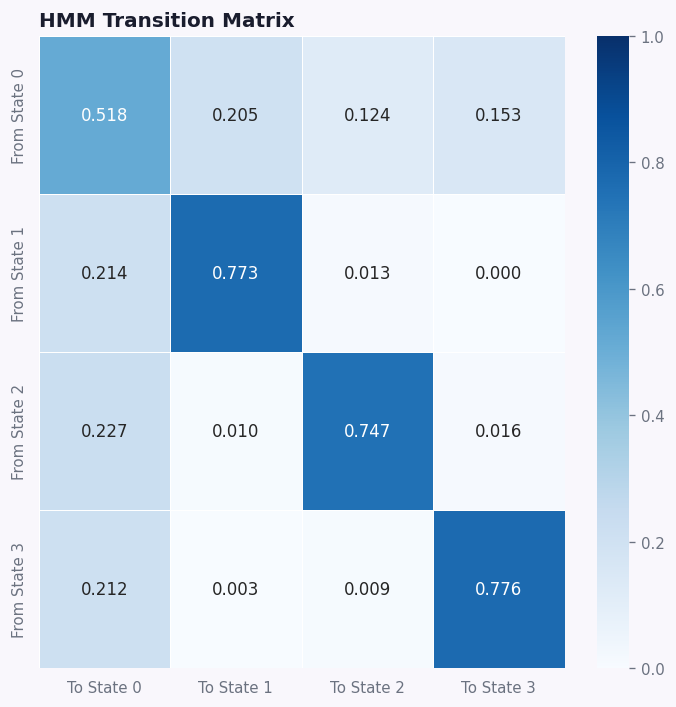

Transition matrix:
              To State 0  To State 1  To State 2  To State 3
From State 0      0.5180      0.2050      0.1235      0.1535
From State 1      0.2142      0.7729      0.0130      0.0000
From State 2      0.2267      0.0102      0.7474      0.0156
From State 3      0.2120      0.0031      0.0086      0.7762


In [105]:
transition_df = pd.DataFrame(
    final_model.transmat_,
    index=[f"From State {i}" for i in range(FINAL_N_STATES)],
    columns=[f"To State {j}" for j in range(FINAL_N_STATES)],
)

fig, ax = plt.subplots(figsize=(6, max(4, FINAL_N_STATES + 2)))
sns.heatmap(
    transition_df,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("HMM Transition Matrix")
plt.tight_layout()
plt.show()

print("Transition matrix:")
print(transition_df.round(4))

<div class="alert alert-block alert-info">
<b>Transition structure:</b> States 1, 2, and 3 are relatively persistent with self-transition probabilities between 0.75 and 0.78, meaning each regime is expected to last several consecutive days once entered. State 0 is the exception with a self-transition of only 0.52 and non-negligible transition probabilities toward every other state, suggesting it functions as a neutral transit state rather than a structurally distinct market regime.
</div>

## Regime persistence
Expected regime duration is computed from the learned self-transition probabilities:

$$
\mathbb{E}[\text{duration of state } i] = \frac{1}{1 - A_{ii}}
$$

In [106]:
regime_series = daily_features_clean_df["hmm_regime"]
transitions = (regime_series != regime_series.shift(1)).sum() - 1

total_days = len(regime_series)
print(f"Total trading days:       {total_days}")
print(f"Total regime transitions: {transitions}")
print(f"Average regime duration:  {total_days / (transitions + 1):.1f} days")

print("\nExpected duration per state (from learned self-transition probabilities):")
for i in range(FINAL_N_STATES):
    p_self = final_model.transmat_[i, i]
    expected_duration = 1.0 / (1.0 - p_self) if p_self < 1.0 else float("inf")
    print(f"  State {i}: {expected_duration:.1f} days  (p_self={p_self:.4f})")

Total trading days:       2144
Total regime transitions: 662
Average regime duration:  3.2 days

Expected duration per state (from learned self-transition probabilities):
  State 0: 2.1 days  (p_self=0.5180)
  State 1: 4.4 days  (p_self=0.7729)
  State 2: 4.0 days  (p_self=0.7474)
  State 3: 4.5 days  (p_self=0.7762)


## Feature distributions by regime
Histograms of the most informative features across regimes confirm whether the detected states are economically meaningful.

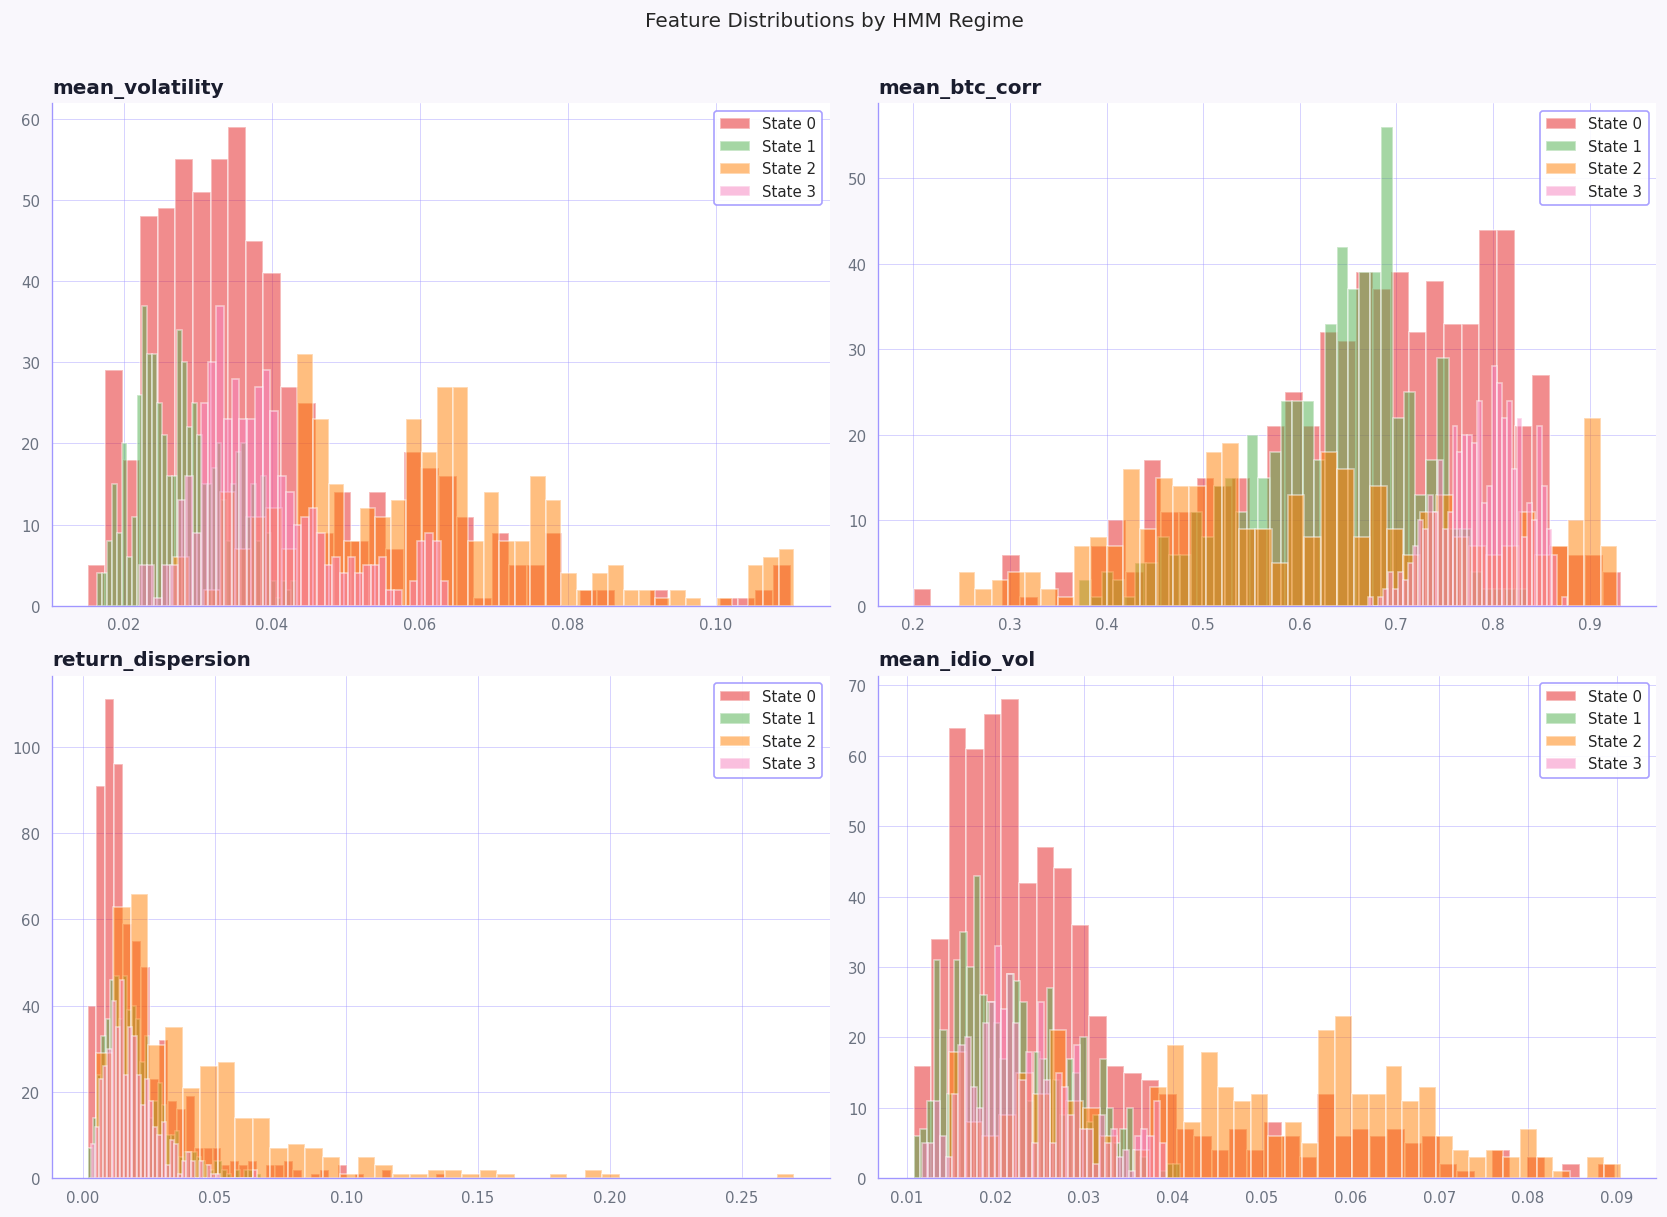

In [107]:
key_features = ["mean_volatility", "mean_btc_corr", "return_dispersion", "mean_idio_vol"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for state in range(FINAL_N_STATES):
        mask = daily_features_clean_df["hmm_regime"] == state
        axes[i].hist(
            daily_features_clean_df.loc[mask, feat],
            bins=40,
            alpha=0.5,
            label=f"State {state}",
            color=colors[state],
        )
    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle("Feature Distributions by HMM Regime", y=1.01)
plt.tight_layout()
plt.show()

## Posterior state probabilities
The posterior probability of being in each state at every time step is computed with the forward-backward algorithm. Plotting these probabilities shows how certain the model is about the regime assignment on each day.

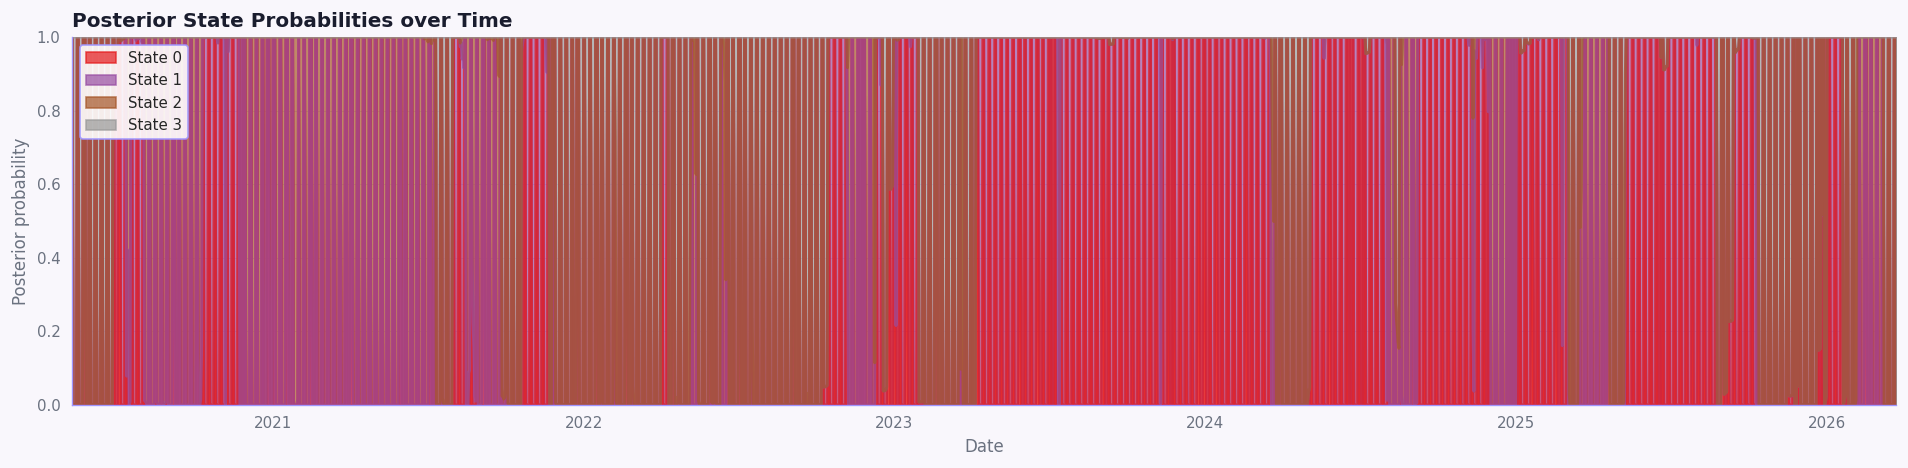

In [108]:
posterior_probs = final_model.predict_proba(X_scaled)

posterior_df = pd.DataFrame(
    posterior_probs,
    index=daily_features_clean_df.index,
    columns=[f"State {i}" for i in range(FINAL_N_STATES)],
)

fig, ax = plt.subplots(figsize=(16, 4))
posterior_df.plot.area(ax=ax, alpha=0.7, colormap="Set1")
ax.set_ylabel("Posterior probability")
ax.set_xlabel("Date")
ax.set_title("Posterior State Probabilities over Time")
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<b>Regime stability concern:</b> The posterior plot shows near-daily switching between states with no single state dominating for any meaningful stretch of time. This is confirmed by the average regime duration of 3.2 days. For market regime analysis, meaningful regimes are expected to persist for weeks to months. The short durations suggest the model is partly capturing day-to-day noise in addition to genuine structural shifts. This limitation should be kept in mind when using the HMM regime labels as features in the LSTM notebook.
</div>

## Save regime labels

The decoded regime labels and posterior probabilities are saved to disk. These will be used as additional features in the LSTM notebook `07_lstm.ipynb`. 

In [109]:
output_df = pd.DataFrame(
    {
        "hmm_regime": regime_labels,
        **{f"hmm_prob_state_{i}": posterior_probs[:, i] for i in range(FINAL_N_STATES)},
    },
    index=daily_features_clean_df.index,
)

output_df.to_csv(HMM_REGIME_LABELS_OUTPUT_PATH)

# Log the saved file as an artifact and close the run opened in the final model cell.
mlflow.log_artifact(str(HMM_REGIME_LABELS_OUTPUT_PATH))
mlflow.end_run()

print(f"Saved {len(output_df)} rows to {HMM_REGIME_LABELS_OUTPUT_PATH}")
output_df.head()

Saved 2144 rows to /home/theodora/PycharmProjects/HSLU_FS26_DSPRO2/data/model_outputs/hmm_regime_labels.csv


,hmm_regime,hmm_prob_state_0,hmm_prob_state_1,hmm_prob_state_2,hmm_prob_state_3
Date,,,,,
2020-05-10,0,1.0,0.000000e+00,0.000000,0.000000
2020-05-11,3,0.0,7.574743e-07,0.000945,0.999054
2020-05-12,3,0.0,3.344586e-12,0.000415,0.999585
2020-05-13,3,0.0,3.089987e-13,0.000006,0.999994
2020-05-14,3,0.0,6.472790e-11,0.000001,0.999999
